<a href="https://colab.research.google.com/github/JohenPerera123/Time-Series-Analysis-of-Toyota-Stock-Prices-1980-2026-/blob/main/Time_Series_Analysis_of_Toyota_Stock_Prices_(1980%E2%80%932026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

In [69]:
df = pd.read_csv("/content/drive/MyDrive/Toyota_Stock_Prices_1980_2026.csv")

In [70]:
print(df.head())

         Date   Close    High     Low    Open  Volume
0  1980-03-18  1.8207  1.8501  1.8207  1.8207    9343
1  1980-03-19  1.8207  1.8207  1.8207  1.8207       0
2  1980-03-20  1.8207  1.8501  1.8207  1.8207   10277
3  1980-03-21  1.8649  1.8944  1.8649  1.8649    8409
4  1980-03-24  1.8723  1.9017  1.8723  1.8723    2803


In [71]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11508 entries, 0 to 11507
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    11508 non-null  object 
 1   Close   11508 non-null  float64
 2   High    11508 non-null  float64
 3   Low     11508 non-null  float64
 4   Open    11508 non-null  float64
 5   Volume  11508 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 539.6+ KB
None


In [72]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df.set_index('Date', inplace=True)

print(df.head())

             Close    High     Low    Open  Volume
Date                                              
1980-03-18  1.8207  1.8501  1.8207  1.8207    9343
1980-03-19  1.8207  1.8207  1.8207  1.8207       0
1980-03-20  1.8207  1.8501  1.8207  1.8207   10277
1980-03-21  1.8649  1.8944  1.8649  1.8649    8409
1980-03-24  1.8723  1.9017  1.8723  1.8723    2803


In [73]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11508 entries, 1980-03-18 to 2026-01-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   11508 non-null  float64
 1   High    11508 non-null  float64
 2   Low     11508 non-null  float64
 3   Open    11508 non-null  float64
 4   Volume  11508 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 539.4 KB
None


In [74]:
print(df.isnull().sum())

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


## Exploratory Data Analysis (EDA)

### summery statistics

In [75]:
print(df.describe())

              Close          High           Low          Open        Volume
count  11508.000000  11508.000000  11508.000000  11508.000000  1.150800e+04
mean      56.436218     56.761133     56.110388     56.444586  2.192929e+05
std       51.051420     51.318871     50.747118     51.047030  3.851212e+05
min        1.783800      1.783800      1.783800      1.783800  0.000000e+00
25%       15.771775     15.879500     15.771775     15.816300  1.425875e+04
50%       41.571500     41.877000     41.185550     41.563900  1.051880e+05
75%       85.989425     86.359250     85.546600     86.017375  3.029250e+05
max      243.764100    245.745900    242.787700    245.262500  1.858270e+07


### plot closing price

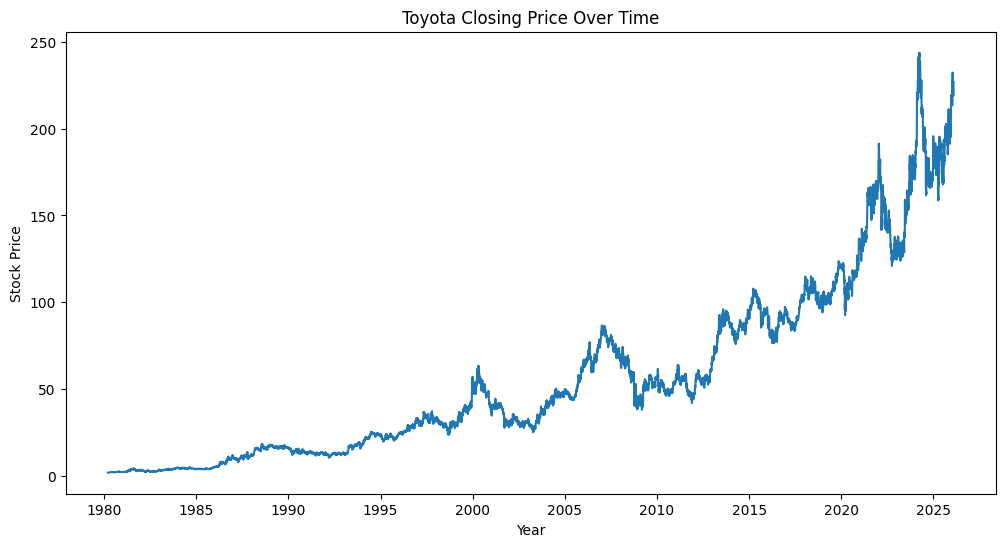

In [76]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("Toyota Closing Price Over Time")
plt.xlabel("Year")
plt.ylabel("Stock Price")
plt.show()

### volume plot

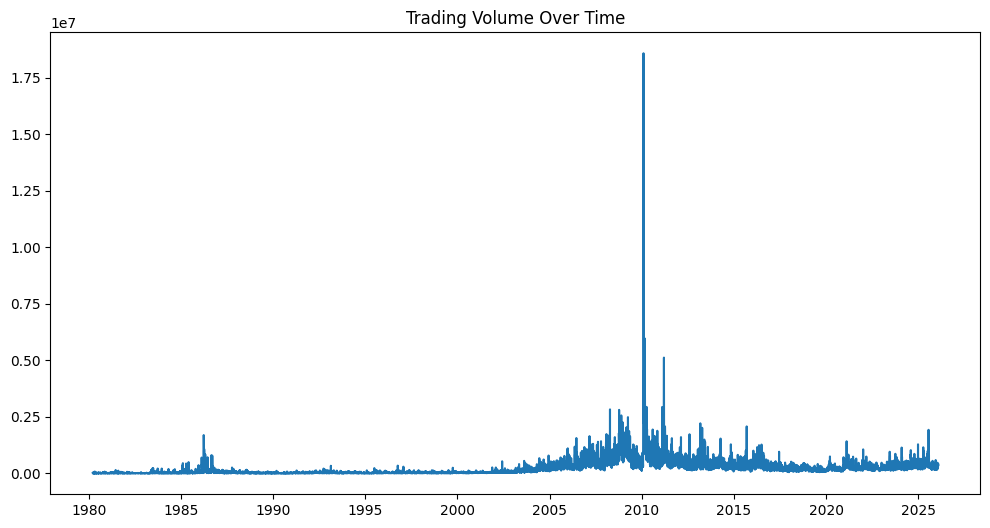

In [77]:
plt.figure(figsize=(12,6))
plt.plot(df['Volume'])
plt.title("Trading Volume Over Time")
plt.show()

##Time Series Decomposition

### **Detect trend, seasonal, irregular components**

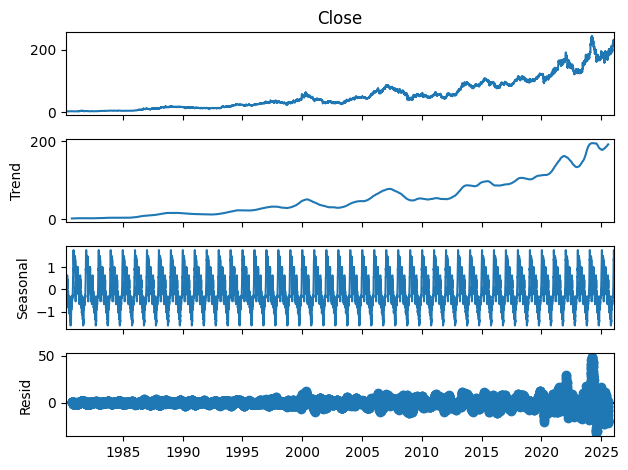

In [78]:
decomposition = seasonal_decompose(df['Close'], model='additive', period=252)

decomposition.plot()
plt.show()

### Components individually

In [79]:
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

## Create Time Variable for Regression

In [80]:
df['t'] = np.arange(len(df))

print(df.head())

             Close    High     Low    Open  Volume  t
Date                                                 
1980-03-18  1.8207  1.8501  1.8207  1.8207    9343  0
1980-03-19  1.8207  1.8207  1.8207  1.8207       0  1
1980-03-20  1.8207  1.8501  1.8207  1.8207   10277  2
1980-03-21  1.8649  1.8944  1.8649  1.8649    8409  3
1980-03-24  1.8723  1.9017  1.8723  1.8723    2803  4


##Linear Regression Model

###Model:

Close=β0​+β1​t


In [81]:
X = df[['t']]
y = df['Close']

linear_model = LinearRegression()
linear_model.fit(X, y)

df['linear_prediction'] = linear_model.predict(X)

In [82]:
print("R2 Score:", r2_score(y, df['linear_prediction']))

rmse = np.sqrt(mean_squared_error(y, df['linear_prediction']))
print("RMSE:", rmse)

R2 Score: 0.8233077364307423
RMSE: 21.458419334783294


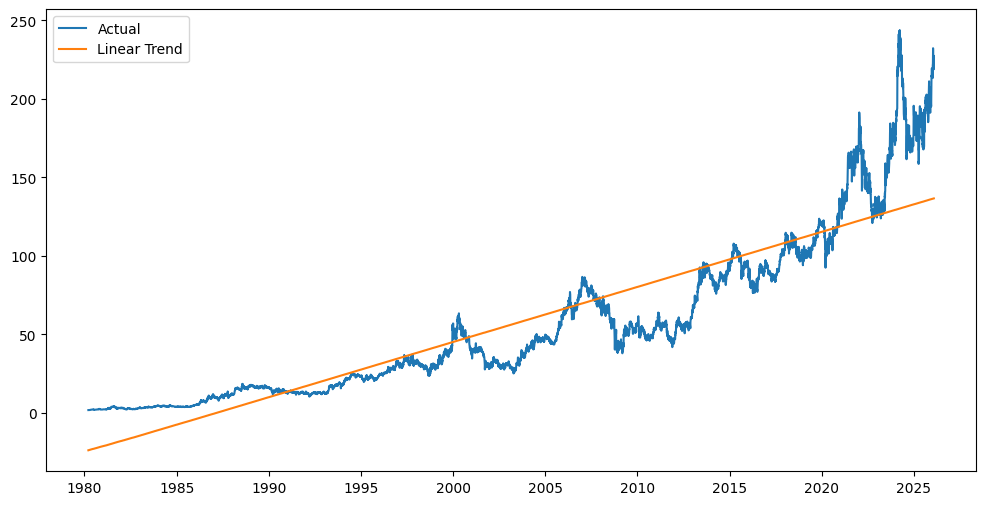

In [83]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Actual')
plt.plot(df['linear_prediction'], label='Linear Trend')
plt.legend()
plt.show()

##Residual Analysis

###Calculate residuals

In [84]:
df['residuals'] = df['Close'] - df['linear_prediction']

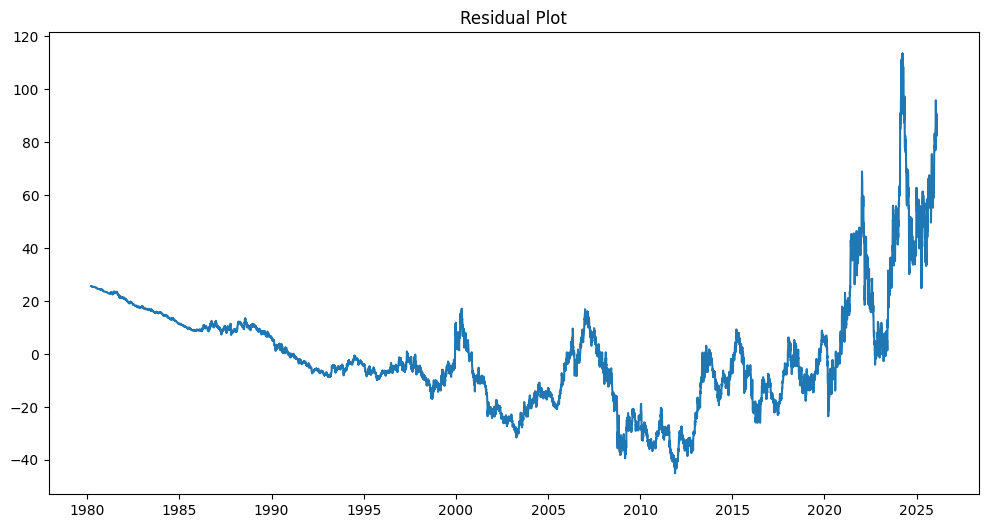

In [85]:
plt.figure(figsize=(12,6))
plt.plot(df['residuals'])
plt.title("Residual Plot")
plt.show()

###histrogram of residuls

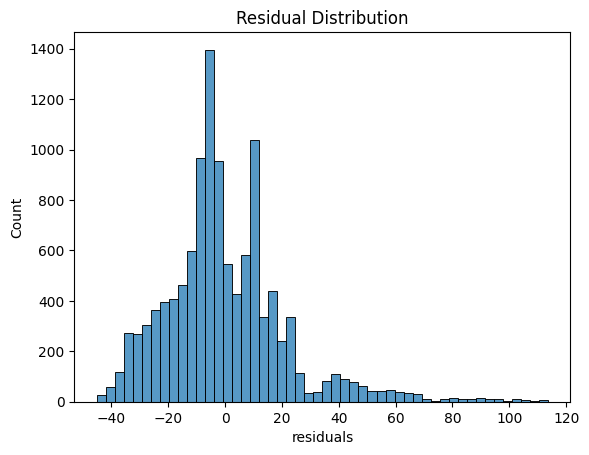

In [86]:
sns.histplot(df['residuals'], bins=50)
plt.title("Residual Distribution")
plt.show()

## Polynomial Regression Model

###Model:

**<center> Close = β<sub>0</sub>+β<sub>1</sub>t+β<sub>2</sub>t<sup>2</sup> </center>**

In [87]:
poly_model = make_pipeline(PolynomialFeatures(2), LinearRegression())

poly_model.fit(X, y)

df['poly_prediction'] = poly_model.predict(X)

In [88]:
print("R2 Score:", r2_score(y, df['poly_prediction']))

rmse = np.sqrt(mean_squared_error(y, df['poly_prediction']))
print("RMSE:", rmse)

R2 Score: 0.9234654027555274
RMSE: 14.122704145734636


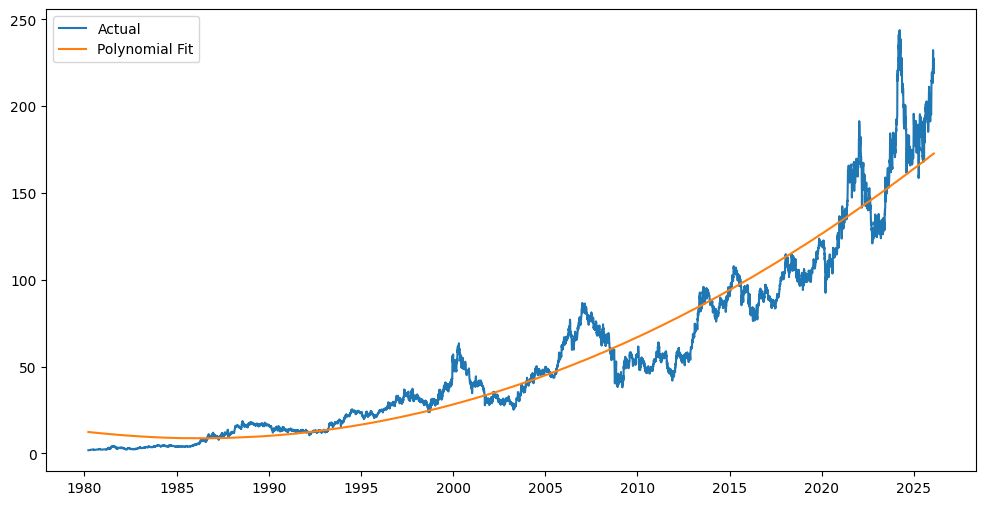

In [89]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Actual')
plt.plot(df['poly_prediction'], label='Polynomial Fit')
plt.legend()
plt.show()

##Multiple Linear Regression

###Predict Close price using other variables.

<Center>Close  =  β<sub>0​</sub> + β<sub>1​</sub>​Open + β<sub>2​</sub>​High + β<sub>03</sub>​Low + β<sub>4</sub>​Volume </center>

In [90]:
X = df[['Open','High','Low','Volume']]
y = df['Close']

mlr_model = LinearRegression()
mlr_model.fit(X, y)

df['mlr_prediction'] = mlr_model.predict(X)

In [91]:
print("R2 Score:", r2_score(y, df['mlr_prediction']))

rmse = np.sqrt(mean_squared_error(y, df['mlr_prediction']))
print("RMSE:", rmse)

R2 Score: 0.9999715943136903
RMSE: 0.27207685826358163


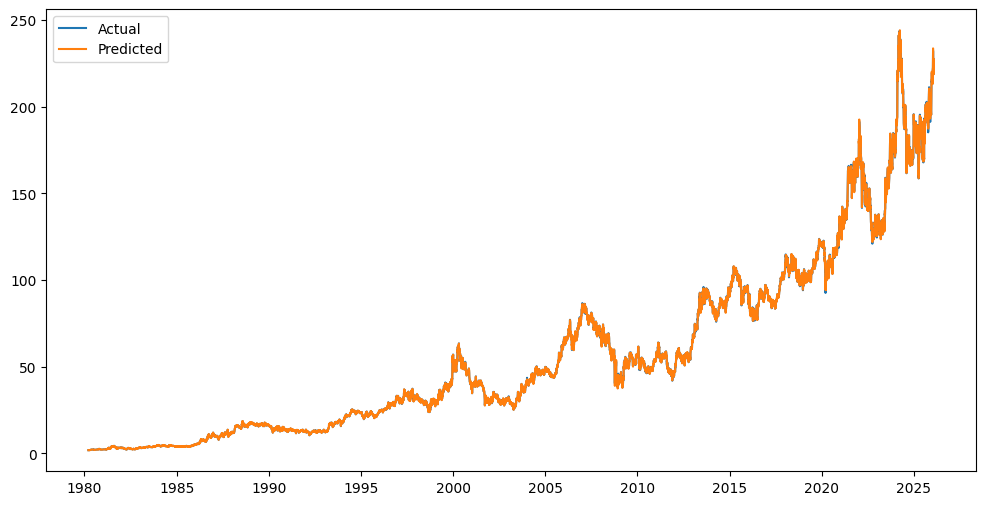

In [92]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Actual')
plt.plot(df['mlr_prediction'], label='Predicted')
plt.legend()
plt.show()

##Stationarity Test (ADF Test)

###Use Augmented Dickey-Fuller Test

*   p-value < 0.05 → Stationary
*   p-value > 0.05 → Non-stationary

In [93]:
result = adfuller(df['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

for key,value in result[4].items():
    print(key, value)

ADF Statistic: 1.2013581408374048
p-value: 0.9959952532025635
1% -3.430920398923597
5% -2.8617920859455794
10% -2.566904180253232


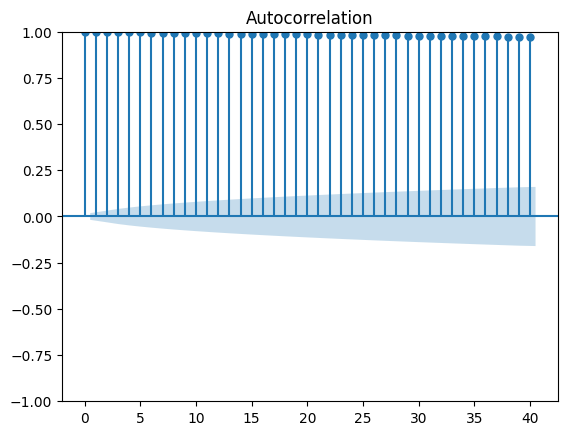

In [94]:
plot_acf(df['Close'].dropna(), lags=40)
plt.show()

##Differencing (Make Series Stationary)

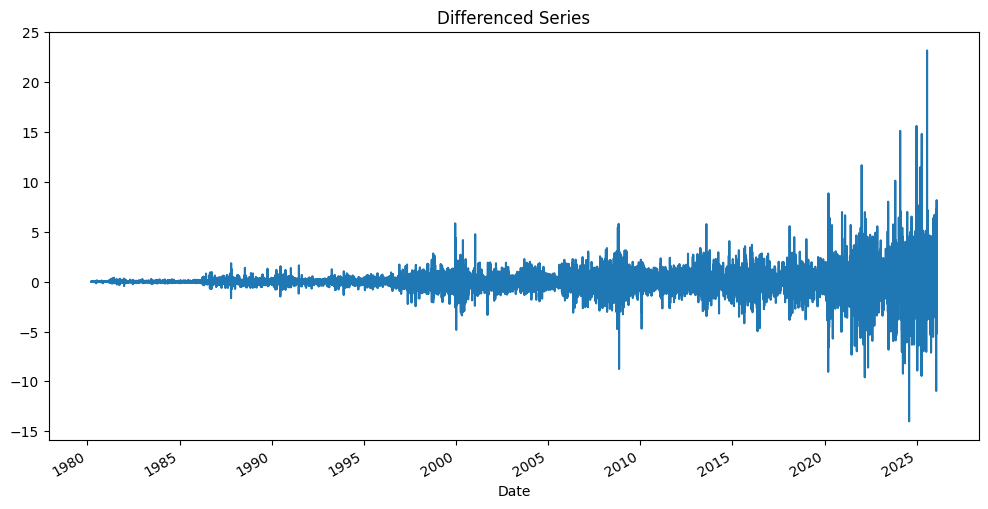

In [95]:
df['Close_diff'] = df['Close'].diff()

df['Close_diff'].dropna().plot(figsize=(12,6))
plt.title("Differenced Series")
plt.show()

In [96]:
result = adfuller(df['Close_diff'].dropna())
print("New p-value:", result[1])

New p-value: 1.0164591972952158e-29


##Autocorrelation Analysis

ACF plot

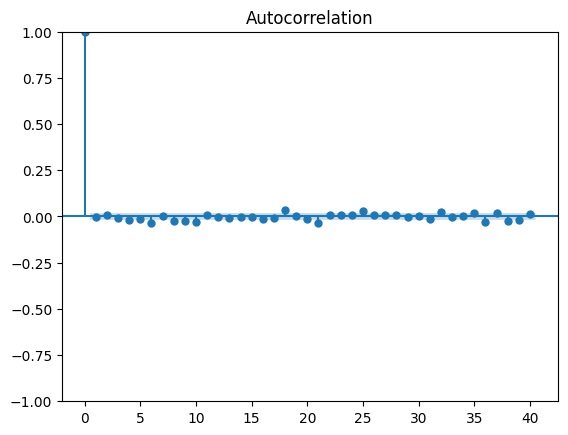

In [97]:
plot_acf(df['Close_diff'].dropna(), lags=40)
plt.show()

PACF plot


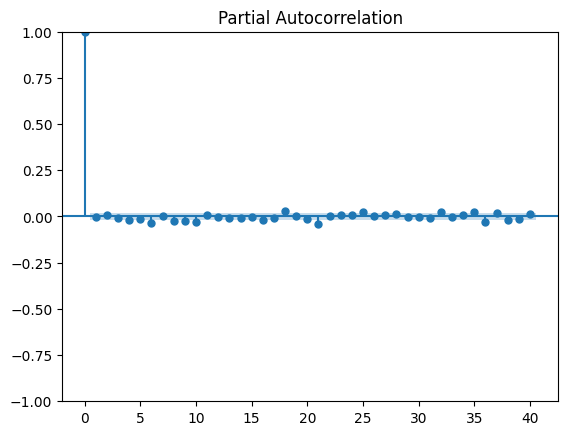

In [98]:
plot_pacf(df['Close_diff'].dropna(), lags=40)
plt.show()

those are help to determine p and q parameters.

In [99]:
from statsmodels.tsa.ar_model import AutoReg

aic_values = []

for i in range(1, 40):

    model = AutoReg(df['Close'], lags=i).fit()

    aic_values.append(model.aic)

print(aic_values)

[np.float64(36944.82480557418), np.float64(36944.56303355307), np.float64(36943.856345427535), np.float64(36943.20983542326), np.float64(36938.413914504694), np.float64(36935.10612953379), np.float64(36921.202957104106), np.float64(36920.95304637385), np.float64(36913.877498961265), np.float64(36906.86980015235), np.float64(36895.10595745663), np.float64(36894.43684143215), np.float64(36894.04104590454), np.float64(36892.462794834544), np.float64(36891.71561517009), np.float64(36891.108248400524), np.float64(36886.63586333754), np.float64(36885.08260262662), np.float64(36872.79378996391), np.float64(36872.5810443798), np.float64(36869.95046054795), np.float64(36852.30642251223), np.float64(36851.906882223375), np.float64(36851.41457940682), np.float64(36850.6205580361), np.float64(36843.60553102698), np.float64(36843.134364810736), np.float64(36842.29804130306), np.float64(36840.65710246418), np.float64(36840.2916786921), np.float64(36840.075389996746), np.float64(36838.70776581356), n

In [100]:
best_p = aic_values.index(min(aic_values)) + 1

print("Best lag (p) =", best_p)

Best lag (p) = 39


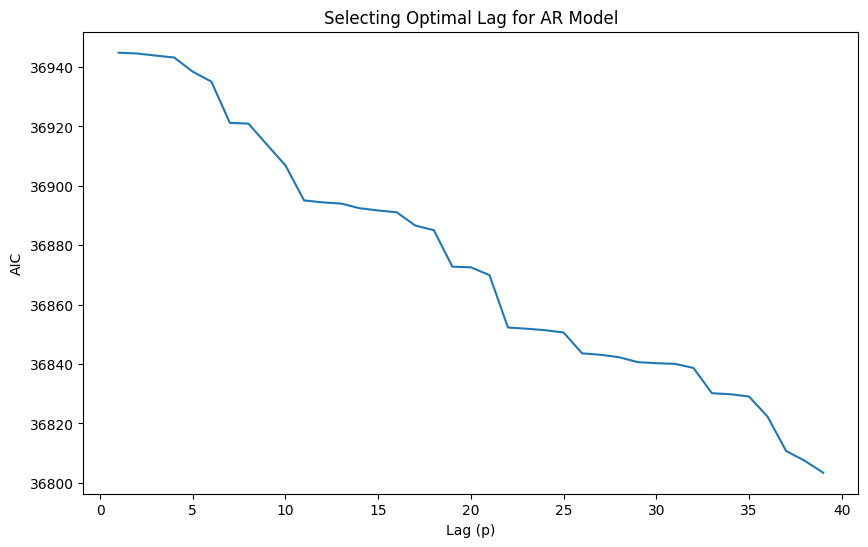

In [101]:
plt.figure(figsize=(10,6))

plt.plot(range(1,40), aic_values)

plt.xlabel("Lag (p)")
plt.ylabel("AIC")
plt.title("Selecting Optimal Lag for AR Model")

plt.show()

In [102]:
bic_values = []

for i in range(1,41):
    model = AutoReg(df['Close'], lags=i).fit()
    bic_values.append(model.bic)

best_p = bic_values.index(min(bic_values)) + 1
print("Best lag using BIC =", best_p)

Best lag using BIC = 1


##Autoregressive Model AR(p)

In [103]:
ar_model = AutoReg(df['Close'], lags=1)

ar_result = ar_model.fit()

print(ar_result.summary())

                            AutoReg Model Results                             
Dep. Variable:                  Close   No. Observations:                11508
Model:                     AutoReg(1)   Log Likelihood              -18469.412
Method:               Conditional MLE   S.D. of innovations              1.205
Date:                Mon, 02 Mar 2026   AIC                          36944.825
Time:                        08:47:09   BIC                          36966.877
Sample:                             1   HQIC                         36952.238
                                11508                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0107      0.017      0.641      0.521      -0.022       0.044
Close.L1       1.0002      0.000   4544.806      0.000       1.000       1.001
                                    Roots           

In [104]:
ar_forecast = ar_result.predict(start=len(df), end=len(df)+30)

print(ar_forecast)

11508    226.906198
11509    226.952404
11510    226.998616
11511    227.044836
11512    227.091063
11513    227.137297
11514    227.183539
11515    227.229788
11516    227.276044
11517    227.322307
11518    227.368577
11519    227.414855
11520    227.461140
11521    227.507432
11522    227.553732
11523    227.600038
11524    227.646352
11525    227.692673
11526    227.739001
11527    227.785337
11528    227.831680
11529    227.878030
11530    227.924387
11531    227.970752
11532    228.017124
11533    228.063503
11534    228.109889
11535    228.156283
11536    228.202683
11537    228.249091
11538    228.295507
dtype: float64


##Moving Average Model (MA)
using MRIMA

In [105]:
import statsmodels.api as sm

for q in range(1, 6):  # try q = 1 to 5
    model = sm.tsa.ARIMA(df['Close_diff'], order=(0,0,q))
    result = model.fit()
    print(f"MA({q}) - AIC: {result.aic}")

MA(1) - AIC: 36945.2876902916
MA(2) - AIC: 36946.74429375639
MA(3) - AIC: 36948.32413305833
MA(4) - AIC: 36945.81417483349
MA(5) - AIC: 36943.96822785166


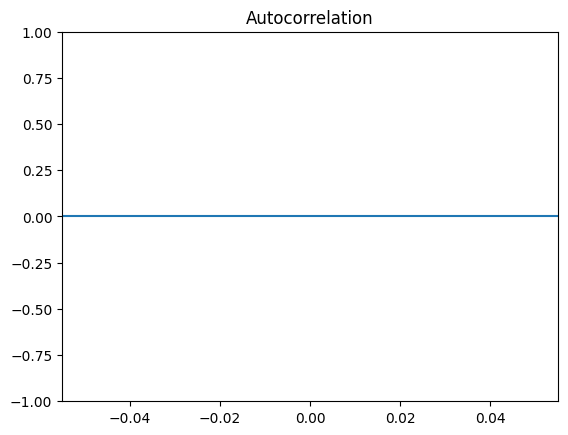

In [106]:
residuals = result.resid
plot_acf(residuals, lags=20)
plt.show()

In [107]:
ma_model = ARIMA(df['Close_diff'], order=(0,0,5))  # MA(5)
ma_result = ma_model.fit()
print(ma_result.summary())

                               SARIMAX Results                                
Dep. Variable:             Close_diff   No. Observations:                11508
Model:                 ARIMA(0, 0, 5)   Log Likelihood              -18464.984
Date:                Mon, 02 Mar 2026   AIC                          36943.968
Time:                        08:47:41   BIC                          36995.424
Sample:                             0   HQIC                         36961.265
                              - 11508                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0196      0.011      1.795      0.073      -0.002       0.041
ma.L1         -0.0037      0.004     -0.914      0.361      -0.012       0.004
ma.L2          0.0054      0.004      1.235      0.2

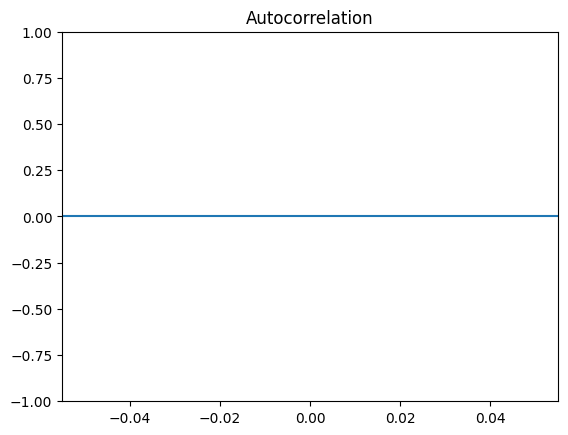

In [108]:
residuals = ma_result.resid
plot_acf(residuals)
plt.show()

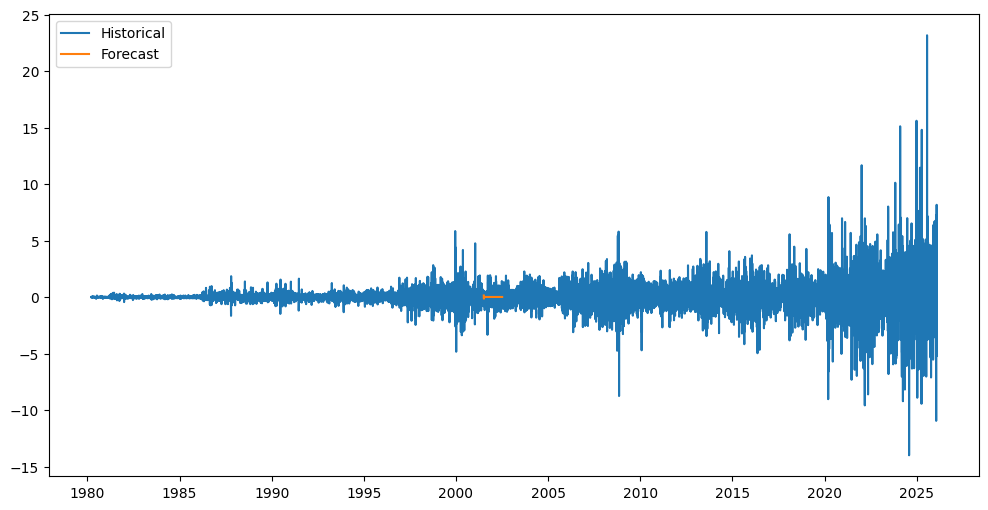

11508    0.151219
11509    0.098602
11510   -0.054023
11511   -0.130054
11512    0.023683
11513    0.019551
11514    0.019551
11515    0.019551
11516    0.019551
11517    0.019551
11518    0.019551
11519    0.019551
11520    0.019551
11521    0.019551
11522    0.019551
11523    0.019551
11524    0.019551
11525    0.019551
11526    0.019551
11527    0.019551
11528    0.019551
11529    0.019551
11530    0.019551
11531    0.019551
11532    0.019551
11533    0.019551
11534    0.019551
11535    0.019551
11536    0.019551
11537    0.019551
11538    0.019551
Name: predicted_mean, dtype: float64


In [109]:
forecast = ma_result.forecast(steps=365)

plt.figure(figsize=(12,6))
plt.plot(df['Close_diff'], label='Historical')
plt.plot(range(len(df), len(df)+365), forecast, label='Forecast')
plt.legend()
plt.show()

ma_forecast = ma_result.predict(start=len(df), end=len(df)+30)

print(ma_forecast)

##ARIMA model


find best (p,d,q)

<Figure size 1200x500 with 0 Axes>

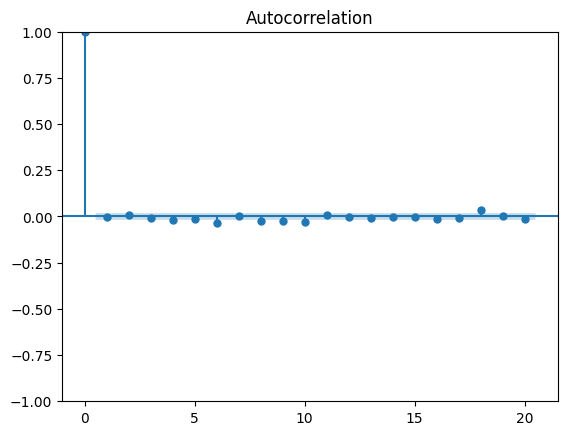

<Figure size 1200x500 with 0 Axes>

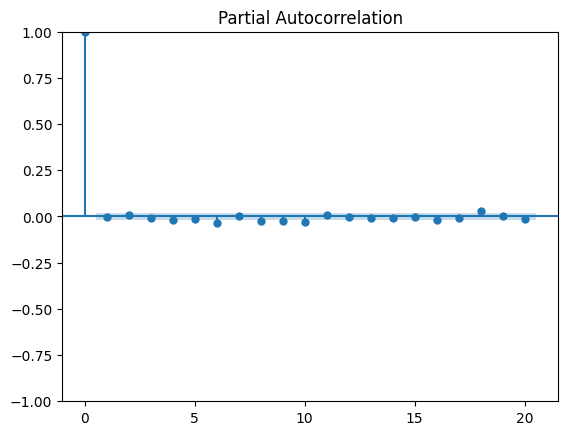

In [110]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plot_acf(df['Close'].diff().dropna(), lags=20)  # for q
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(df['Close'].diff().dropna(), lags=20)  # for p
plt.show()

In [111]:
arima_model = ARIMA(df['Close_diff'], order=(1,1,2))

arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:             Close_diff   No. Observations:                11508
Model:                 ARIMA(1, 1, 2)   Log Likelihood              -18480.425
Date:                Mon, 02 Mar 2026   AIC                          36968.850
Time:                        08:47:52   BIC                          36998.253
Sample:                             0   HQIC                         36978.733
                              - 11508                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9878      0.011    -89.423      0.000      -1.009      -0.966
ma.L1         -0.0104      0.010     -1.008      0.313      -0.031       0.010
ma.L2         -0.9891      0.010    -95.542      0.0

###Forcast future prices

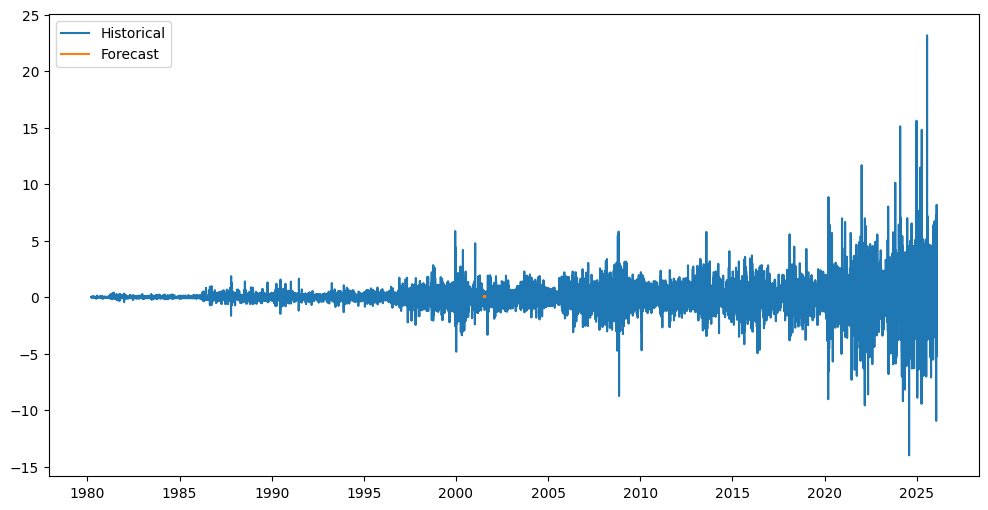

11508    0.017368
11509    0.049532
11510    0.017759
11511    0.049145
11512    0.018141
11513    0.048768
11514    0.018514
11515    0.048400
11516    0.018877
11517    0.048041
11518    0.019232
11519    0.047690
11520    0.019578
11521    0.047348
11522    0.019916
11523    0.047014
11524    0.020246
11525    0.046689
11526    0.020567
11527    0.046371
11528    0.020881
11529    0.046061
11530    0.021188
11531    0.045758
11532    0.021487
11533    0.045463
11534    0.021778
11535    0.045175
11536    0.022063
11537    0.044894
11538    0.022341
Name: predicted_mean, dtype: float64


In [112]:
forecast = arima_result.forecast(steps=30)

plt.figure(figsize=(12,6))
plt.plot(df['Close_diff'], label='Historical')
plt.plot(range(len(df), len(df)+30), forecast, label='Forecast')
plt.legend()
plt.show()

arima_forecast = arima_result.predict(start=len(df), end=len(df)+30)

print(arima_forecast)

##Forecast accuracy

In [113]:
pred = arima_result.predict(start=100, end=500)

rmse = np.sqrt(mean_squared_error(df['Close'][100:501], pred))

print("RMSE:", rmse)

RMSE: 2.8853320310058246


##Final visualization

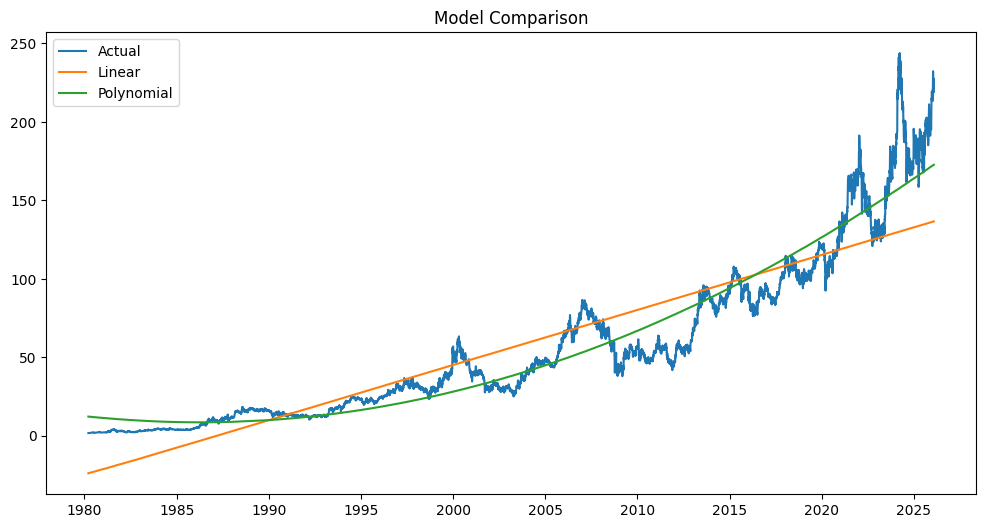

In [114]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Actual')
plt.plot(df['linear_prediction'], label='Linear')
plt.plot(df['poly_prediction'], label='Polynomial')
plt.legend()
plt.title("Model Comparison")
plt.show()

In [115]:
def evaluate_forecast(actual, predicted):
    """
    Compute common error metrics for time series
    """
    mad = np.mean(np.abs(actual - predicted))  # same as MAE
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return {
        "MAD": mad,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE (%)": mape
    }

In [116]:
from sklearn.metrics import mean_absolute_error

# Ensure we use same evaluation range
start_idx = 100
end_idx = 500

# Actual values for Close
actual = df['Close'][start_idx:end_idx+1]

# --- Generate and transform predictions for the evaluation range ---

# AR Model (AutoReg on df['Close'], lags=1)
# Use fittedvalues for robust in-sample predictions
ar_pred = ar_result.fittedvalues.loc[actual.index]

# MA Model (ARIMA on df['Close_diff'], order=(0,0,5))
# Predictions are for 'Close_diff', need inverse differencing
ma_pred_diff_raw = ma_result.predict(start=start_idx, end=end_idx)
ma_pred_diff = pd.Series(ma_pred_diff_raw.values, index=actual.index)

# Inverse transform ma_pred_diff to Close
# We need the last actual Close value before the prediction starts.
ma_pred = pd.Series(df['Close'].iloc[start_idx-1] + ma_pred_diff.cumsum(), index=actual.index)

# ARIMA Model (ARIMA on df['Close_diff'], order=(1,1,2) -> effectively ARIMA(df['Close'], order=(1,2,2)))
# Predictions are for the *second difference* (Close_diff_diff), need double inverse differencing
arima_pred_diff_diff_raw = arima_result.predict(start=start_idx, end=end_idx)
arima_pred_diff_diff = pd.Series(arima_pred_diff_diff_raw.values, index=actual.index)

# Inverse transform 1: from Close_diff_diff to Close_diff
# We need the last actual Close_diff value before the prediction starts.
arima_pred_diff = pd.Series(df['Close_diff'].iloc[start_idx-1] + arima_pred_diff_diff.cumsum(), index=actual.index)

# Inverse transform 2: from Close_diff to Close
# We use the last actual Close value before the prediction starts.
arima_pred = pd.Series(df['Close_diff'].iloc[start_idx-1] + arima_pred_diff.cumsum(), index=actual.index)

# No ARMA model was built, so removing its evaluation.

# Evaluate
metrics_ar = evaluate_forecast(actual, ar_pred)
metrics_ma = evaluate_forecast(actual, ma_pred)
metrics_arima = evaluate_forecast(actual, arima_pred)
metrics_arima_diff = evaluate_forecast(actual, arima_pred_diff)

# Combine into a table
metrics_table = pd.DataFrame([metrics_ar, metrics_ma, metrics_arima,metrics_arima_diff],
                             index=["AR(1)", "MA(5) (on Close_diff)", "ARIMA(1,2,2) (on Close)", "ARIMA(1,1,2)"])
metrics_table

,MAD,MAE,MSE,RMSE,MAPE (%)
AR(1),0.057880,0.057880,0.007954,0.089183,1.954786
MA(5) (on Close_diff),3.385384,3.385384,16.181529,4.022627,119.715657
"ARIMA(1,2,2) (on Close)",90.957074,90.957074,15679.973370,125.219700,3150.505082
"ARIMA(1,1,2)",2.113009,2.113009,4.753121,2.180165,75.217308
